In [33]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import final_forward_attenuation
importlib.reload(final_forward_attenuation)
from final_forward_attenuation import run_simulation, default_species, convert_atm, txt_to_npy, convert_vmr, plot_npy, plot_histogram, downsample, count_lines_by_index

c:\Users\PC\Documents\GitHub\Stand-off
Using species: ['H2O']
DEBUG: H2O iso=1 qfile=TIPS/H2O/q1.txt exists=True
DEBUG: H2O iso=2 qfile=TIPS/H2O/q2.txt exists=True
DEBUG: H2O iso=3 qfile=TIPS/H2O/q3.txt exists=True
DEBUG: H2O iso=4 qfile=TIPS/H2O/q4.txt exists=True
DEBUG: H2O iso=5 qfile=TIPS/H2O/q5.txt exists=True
DEBUG: H2O iso=6 qfile=TIPS/H2O/q6.txt exists=True
DEBUG: H2O iso=7 qfile=TIPS/H2O/q129.txt exists=True


c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:228: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:228: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:228: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:228: FutureWarning: The 'delim_whitespace' keyword in pd.read_

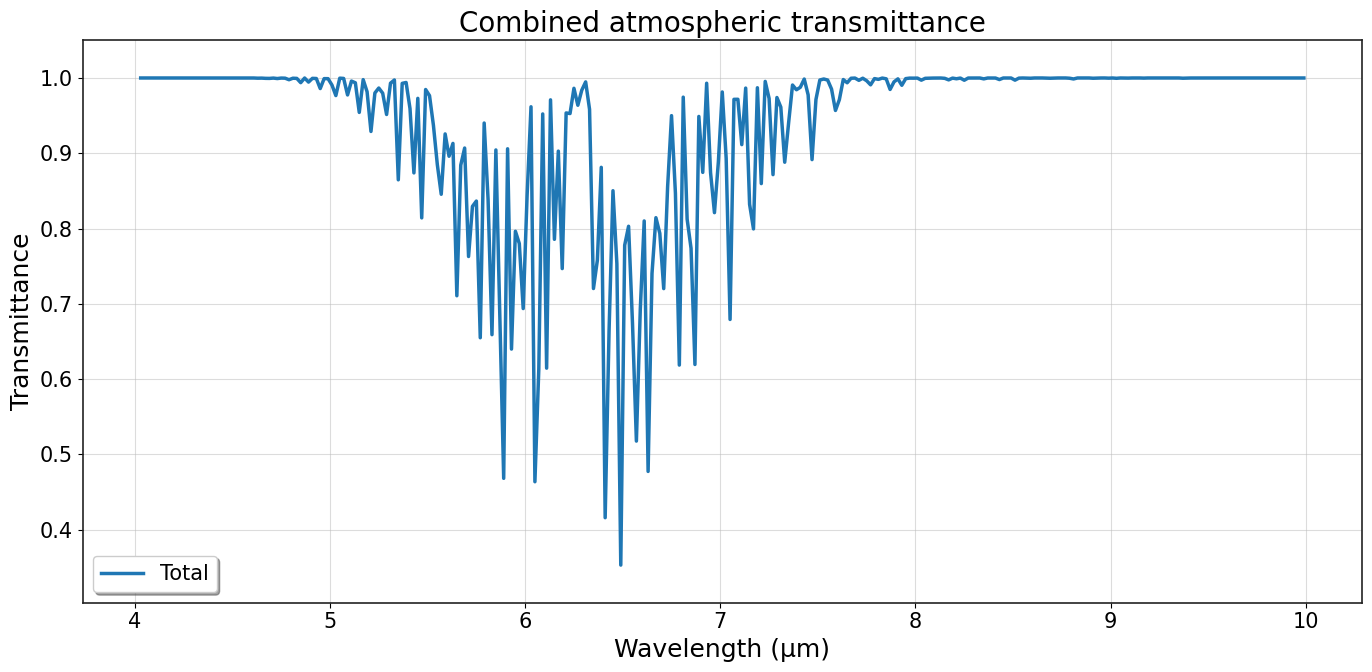

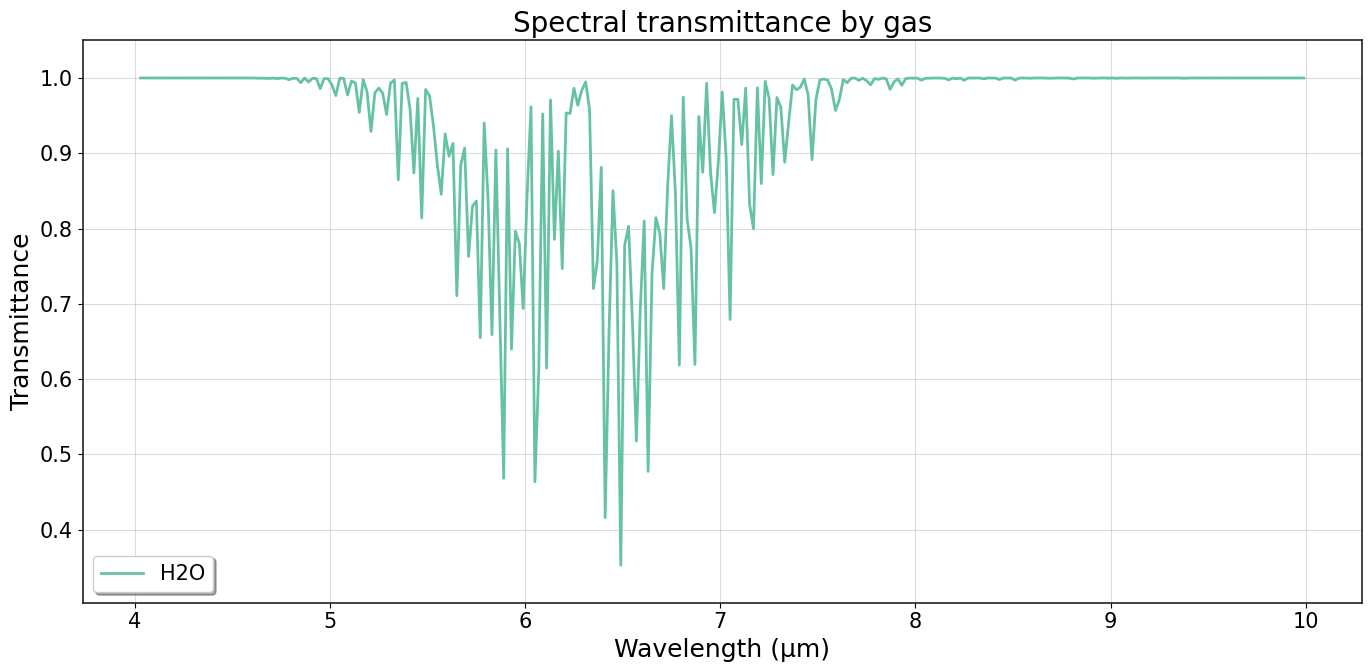

In [ ]:
Ptotal = convert_atm(1013, "mbar")
T = 288.2

sp = default_species()
for s in sp:
     if s.name == 'H2O': s.Pmol = 0.0077480878361707375 
     else: s.Pmol = 0.0
    

import os
print(os.getcwd())

res = run_simulation(
    species=sp,
    parfile='PARS/ALL.par',
    nu_min=1000, nu_max=2500, dnu=0.01,
    tileW=20.0, guard=5.0,
    temp_K=T, L_m=1.0, pres=Ptotal,
    delta_um=0.020,
    save_csv=True, outdir='OUT', make_plots=True, 
    att=False, transmission_npy_name='Simulated_Standard_H2O_4-10_1m.npy',
    use_all_isotopologues=True, species_to_use=['H2O']

)

lambda_um = res['lambda_centers']
Tprod = res['T_prod_samp']
Tco2  = res['T_each_samp'][0]

In [19]:


prueba = np.load("SIMULATED/Simulated_Standard_H2O_4-10_1m.npy")                       # (3, 299)
trans  = np.load("GT_PROFE/Transmittance_Standard_H2O_4-10_1m.npy")        # (2, 644299)

lam_tgt = prueba[0]   # centros objetivo (misma resolución que "Prueba_Isotopologos")
lam_src = trans[0]
tau_src = trans[1]


edges = np.empty(lam_tgt.size + 1)
edges[1:-1] = 0.5 * (lam_tgt[:-1] + lam_tgt[1:])
edges[0]    = lam_tgt[0]  - 0.5 * (lam_tgt[1] - lam_tgt[0])
edges[-1]   = lam_tgt[-1] + 0.5 * (lam_tgt[-1] - lam_tgt[-2])


cum = np.concatenate([[0.0], np.cumsum(0.5 * (tau_src[:-1] + tau_src[1:]) * (lam_src[1:] - lam_src[:-1]))])

def cum_at(x):
    return np.interp(x, lam_src, cum)


area = cum_at(edges[1:]) - cum_at(edges[:-1])
tau_ds = area / (edges[1:] - edges[:-1])

valid = (edges[:-1] >= lam_src[0]) & (edges[1:] <= lam_src[-1])
tau_ds[~valid] = np.nan

out = np.vstack([lam_tgt, tau_ds])
np.save("SIMULATED/Transmittance_Standard_H2O_4-10_1m__downsampled_to_Prueba_Isotopologos.npy", out)


In [ ]:
# sim = np.load("SIMULATED/Simulated_Standard_H2O_4-10_1m.npy")  
# sim = sim[:, :-1]
# sim.shape
# np.save("SIMULATED/Simulated_Standard_H2O_4-10_1m.npy", sim)

In [ ]:
# gt = np.load("SIMULATED/Transmittance_Standard_H2O_4-10_1m__downsampled_to_Prueba_Isotopologos.npy") 
# gt = gt[:, :-1]
# gt.shape
# np.save("SIMULATED/Transmittance_Standard_H2O_4-10_1m__downsampled_to_Prueba_Isotopologos.npy", gt)

In [26]:
gt = np.load("SIMULATED/Transmittance_Standard_H2O_4-10_1m__downsampled_to_Prueba_Isotopologos.npy")
sim = np.load("SIMULATED/Simulated_Standard_H2O_4-10_1m.npy")  
print(gt.shape)
print(sim.shape)

(2, 298)
(2, 298)


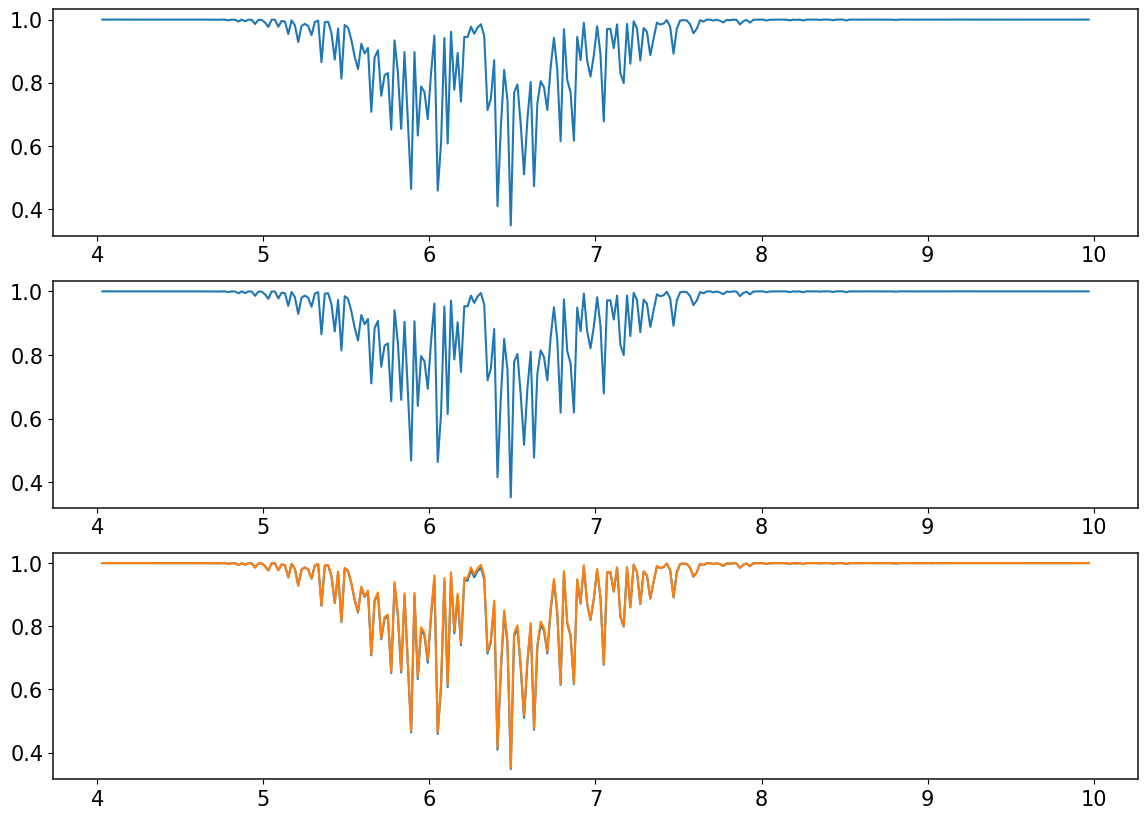

In [27]:
gt = np.load("SIMULATED/Transmittance_Standard_H2O_4-10_1m__downsampled_to_Prueba_Isotopologos.npy")
sim = np.load("SIMULATED/Simulated_Standard_H2O_4-10_1m.npy")  
plt.figure(figsize=(14, 10))
plt.subplot(311)
plt.plot(gt[0], gt[1])
plt.subplot(312)
plt.plot(sim[0], sim[1])
plt.subplot(313)
plt.plot(gt[0], gt[1])
plt.plot(sim[0], sim[1])

In [ ]:
gt[0]-sim[0] #misma resolucion y muestreo

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

MAE: 0.0017273336938085394


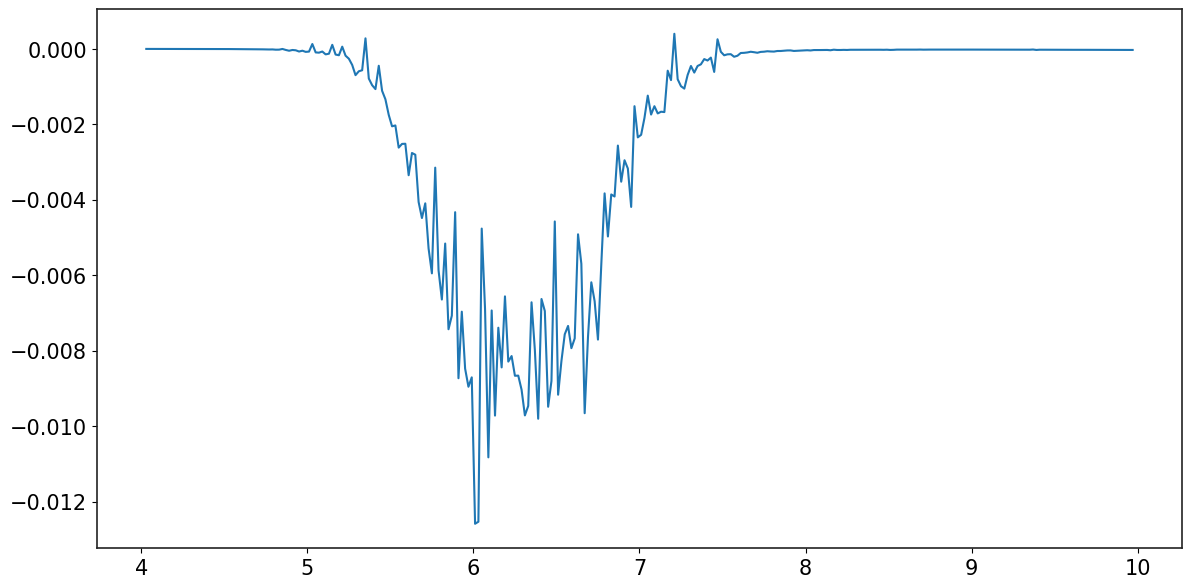

In [ ]:
residual = np.abs((gt[1]-sim[1]))
mae = np.mean(np.abs(gt[1]-sim[1]))
plt.figure(figsize=(14,7))
plt.plot(gt[0], residual)
print("MAE:", mae)

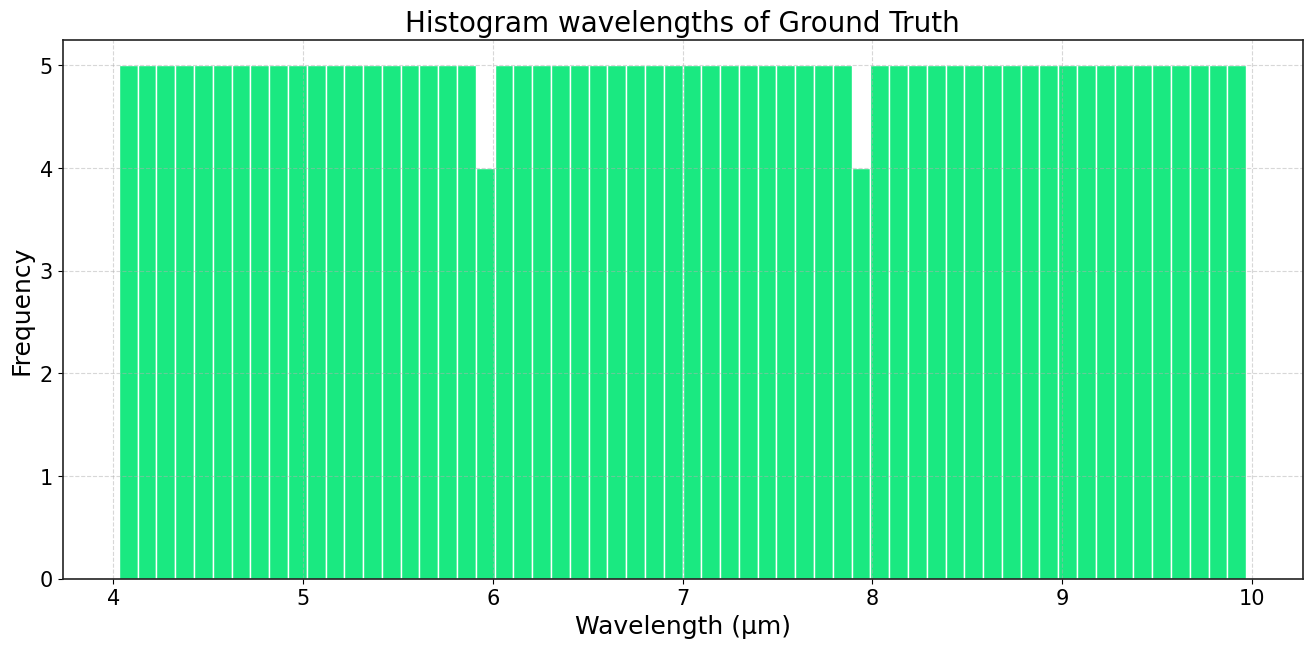

In [29]:
plot_histogram(gt[0],name='Ground Truth')

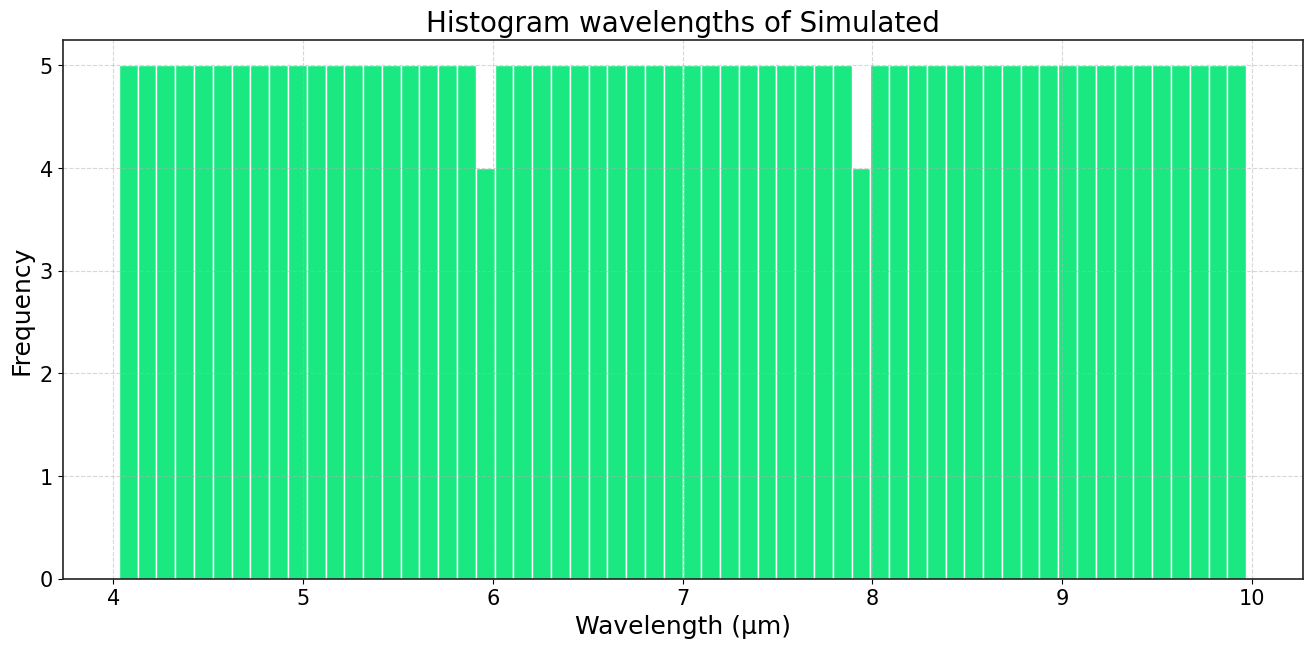

In [30]:
plot_histogram(sim[0],name='Simulated')

CO2

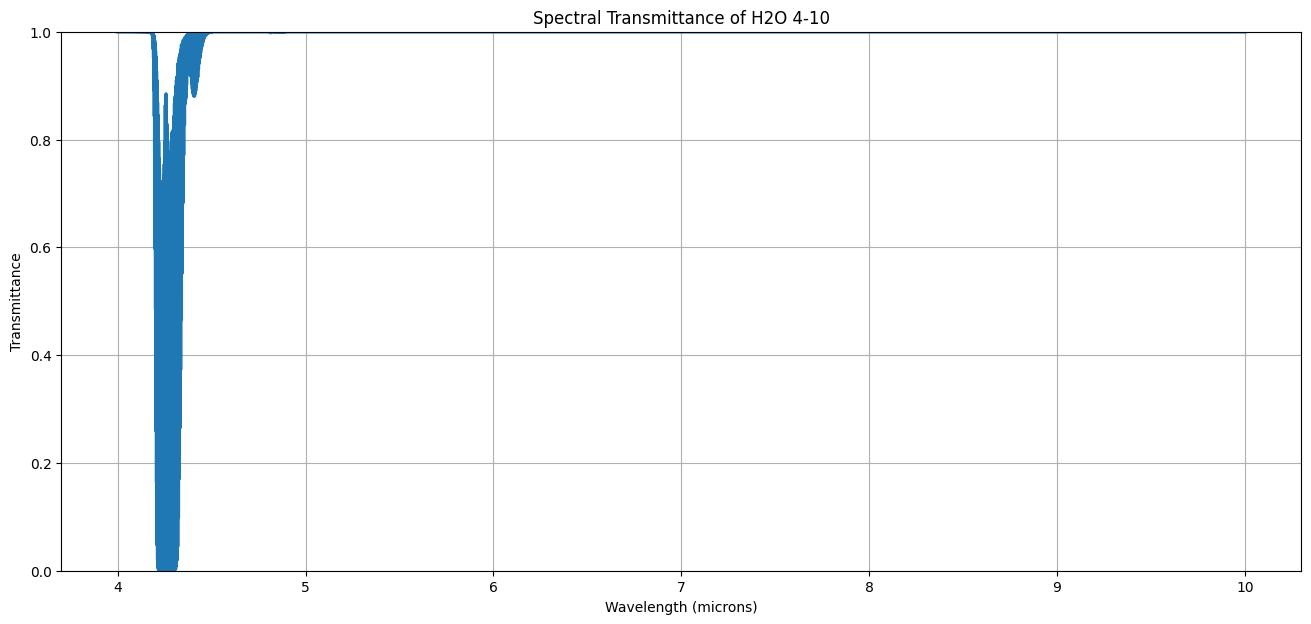

In [7]:
'''ground truth'''
sign = np.load("GT_PROFE/Transmittance_Standard_CO2_4-10_1m.npy")
plot_npy(sign[0], sign[1], name='H2O 4-10')

In [39]:
'''simulated'''
Ptotal = convert_atm(1013, "mbar")
T = 288.2

sp = default_species()
for s in sp:
     if s.name == 'CO2': s.Pmol = 0.0003299185788304959
     else: s.Pmol = 0.0
    

import os
print(os.getcwd())

res = run_simulation(
    species=sp,
    parfile='PARS/ALL.par',
    nu_min=1000, nu_max=2500, dnu=0.01,
    tileW=20.0, guard=5.0,
    temp_K=T, L_m=1.0, pres=Ptotal,
    delta_um=0.020,
    save_csv=True, outdir='OUT', make_plots=False, 
    att=False, transmission_npy_name='Simulated_Standard_CO2_4-10_1m.npy',
    use_all_isotopologues=True, species_to_use=['CO2']

)

lambda_um = res['lambda_centers']
Tprod = res['T_prod_samp']
Tco2  = res['T_each_samp'][0]

c:\Users\PC\Documents\GitHub\Stand-off
Using species: ['CO2']
DEBUG: CO2 iso=1 qfile=TIPS/CO2/q7.txt exists=True
DEBUG: CO2 iso=2 qfile=TIPS/CO2/q8.txt exists=True
DEBUG: CO2 iso=3 qfile=TIPS/CO2/q9.txt exists=True
DEBUG: CO2 iso=4 qfile=TIPS/CO2/q10.txt exists=True
DEBUG: CO2 iso=5 qfile=TIPS/CO2/q11.txt exists=True
DEBUG: CO2 iso=6 qfile=TIPS/CO2/q12.txt exists=True
DEBUG: CO2 iso=7 qfile=TIPS/CO2/q13.txt exists=True
DEBUG: CO2 iso=8 qfile=TIPS/CO2/q14.txt exists=True
DEBUG: CO2 iso=9 qfile=TIPS/CO2/q15.txt exists=True
DEBUG: CO2 iso=10 qfile=TIPS/CO2/q120.txt exists=True
DEBUG: CO2 iso=A qfile=TIPS/CO2/q121.txt exists=True
DEBUG: CO2 iso=B qfile=TIPS/CO2/q122.txt exists=True


c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  with open(path, 'r', errors='ignore') as f:
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  with open(path, 'r', errors='ignore') as f:
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  with open(path, 'r', errors='ignore') as f:
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  

In [34]:
simulated = np.load("SIMULATED/Simulated_Standard_CO2_4-10_1m.npy")
gt = np.load("GT_PROFE/Transmittance_Standard_CO2_4-10_1m.npy")
output = "SIMULATED/Transmittance_Standard_CO2_4-10_1m__downsampled_to_Simulated_Standard_CO2_4-10_1m.npy"
downsample(simulated, gt, output)

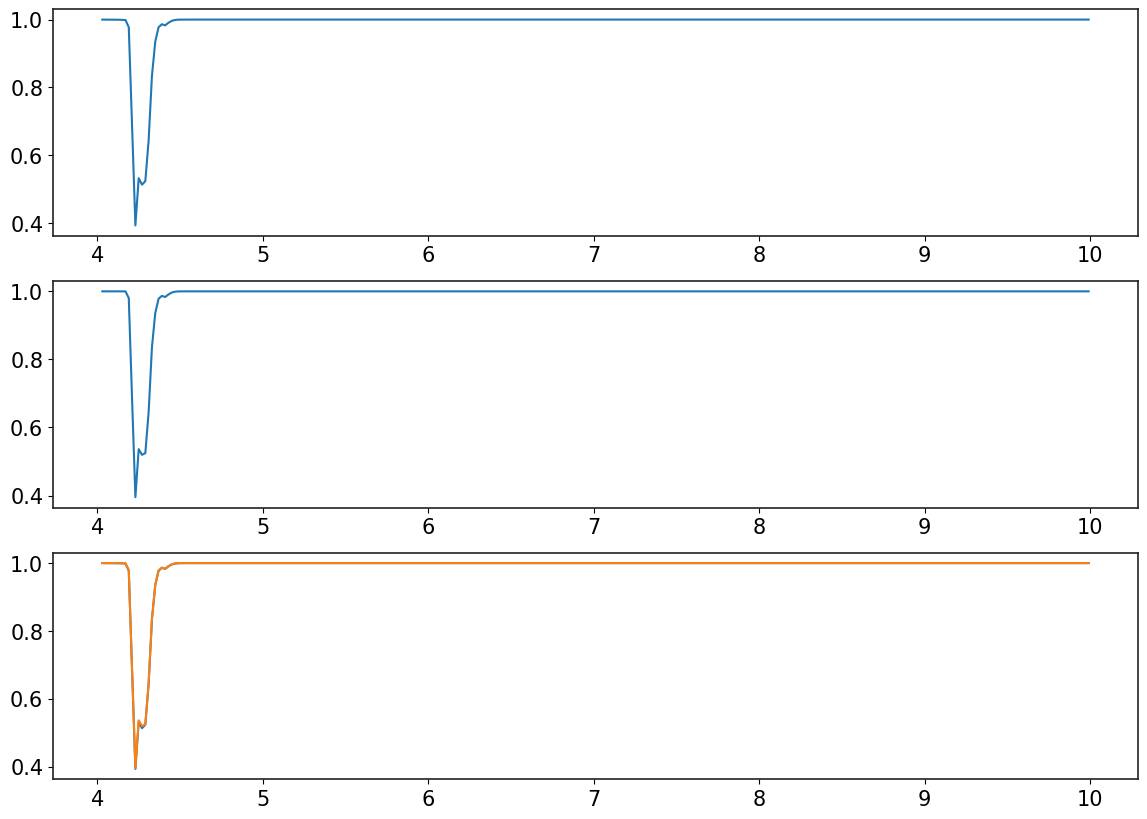

In [35]:
gt = np.load("SIMULATED/Transmittance_Standard_CO2_4-10_1m__downsampled_to_Simulated_Standard_CO2_4-10_1m.npy")
sim = np.load("SIMULATED/Simulated_Standard_CO2_4-10_1m.npy")  
plt.figure(figsize=(14, 10))
plt.subplot(311)
plt.plot(gt[0], gt[1])
plt.subplot(312)
plt.plot(sim[0], sim[1])
plt.subplot(313)
plt.plot(gt[0], gt[1])
plt.plot(sim[0], sim[1])

In [38]:
mae = np.mean(np.abs(gt[1]-sim[1]))
print("MAE:", mae)

MAE: 9.697191273372523e-05


N2O

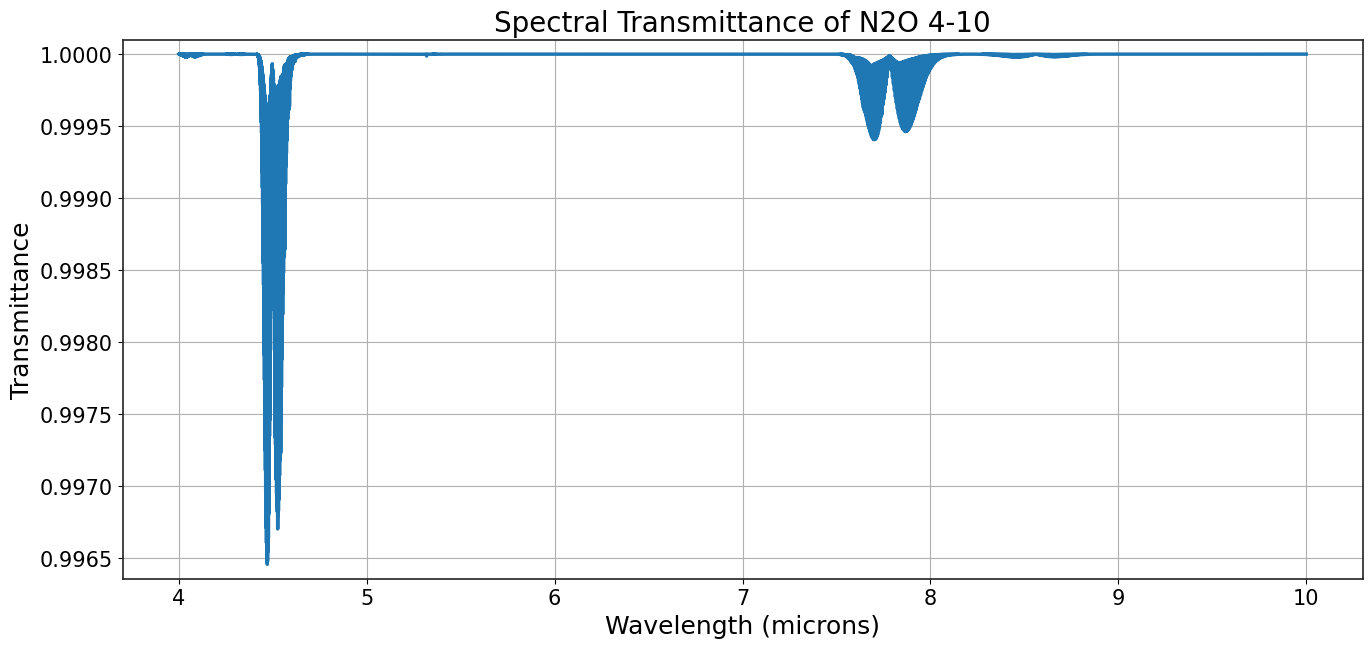

In [44]:
'''N2O 4-10'''
wave, tr = np.load('GT_PROFE/N2O_4-10.npy')
name = 'N2O 4-10'
plot_npy(wave, tr, name=name)

In [45]:
Ptotal = convert_atm(1013, "mbar")
3.2e-07 * Ptotal

3.1992104613866274e-07

In [46]:
'''simulated'''
Ptotal = convert_atm(1013, "mbar")
T = 288.2

sp = default_species()
for s in sp:
     if s.name == 'N2O': s.Pmol = 3.1992104613866274e-07
     else: s.Pmol = 0.0
    

import os
print(os.getcwd())

res = run_simulation(
    species=sp,
    parfile='PARS/ALL.par',
    nu_min=1000, nu_max=2500, dnu=0.01,
    tileW=20.0, guard=5.0,
    temp_K=T, L_m=1.0, pres=Ptotal,
    delta_um=0.020,
    save_csv=True, outdir='OUT', make_plots=False, 
    att=False, transmission_npy_name='Simulated_N2O_4-10_1m.npy',
    use_all_isotopologues=True, species_to_use=['N2O']

)

lambda_um = res['lambda_centers']
Tprod = res['T_prod_samp']
Tco2  = res['T_each_samp'][0]

c:\Users\PC\Documents\GitHub\Stand-off
Using species: ['N2O']
DEBUG: N2O iso=1 qfile=TIPS/N2O/q21.txt exists=True
DEBUG: N2O iso=2 qfile=TIPS/N2O/q22.txt exists=True
DEBUG: N2O iso=3 qfile=TIPS/N2O/q23.txt exists=True
DEBUG: N2O iso=4 qfile=TIPS/N2O/q24.txt exists=True
DEBUG: N2O iso=5 qfile=TIPS/N2O/q25.txt exists=True


c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  with open(path, 'r', errors='ignore') as f:
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  with open(path, 'r', errors='ignore') as f:
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  with open(path, 'r', errors='ignore') as f:
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  

In [47]:
gt = np.load("GT_PROFE/N2O_4-10.npy")
sim = np.load("SIMULATED/Simulated_N2O_4-10_1m.npy")  
output = "SIMULATED/Transmittance_N2O_4-10_1m__downsampled_to_Simulated_N2O_4-10_1m.npy"
downsample(sim, gt, output)

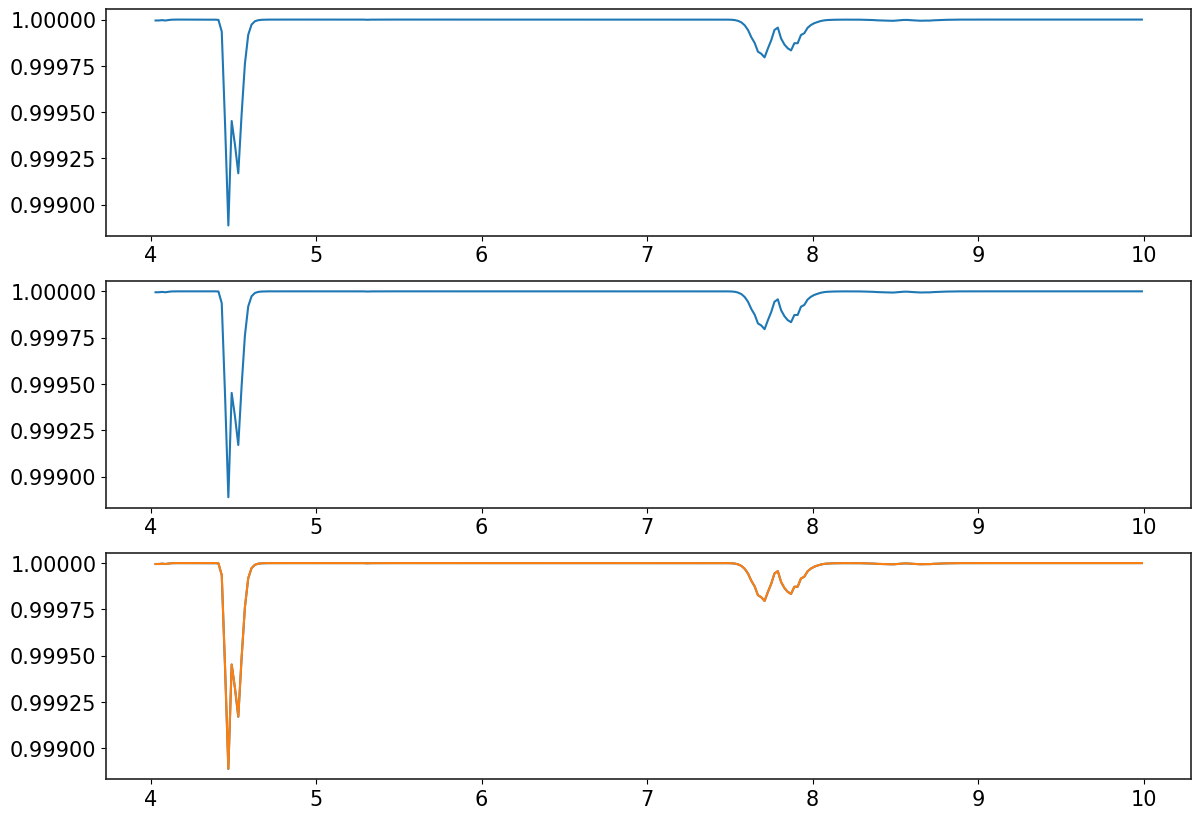

In [48]:
gt = np.load("SIMULATED/Transmittance_N2O_4-10_1m__downsampled_to_Simulated_N2O_4-10_1m.npy")
sim = np.load("SIMULATED/Simulated_N2O_4-10_1m.npy")  
plt.figure(figsize=(14, 10))
plt.subplot(311)
plt.plot(gt[0], gt[1])
plt.subplot(312)
plt.plot(sim[0], sim[1])
plt.subplot(313)
plt.plot(gt[0], gt[1])
plt.plot(sim[0], sim[1])

In [49]:
mae = np.mean(np.abs(gt[1]-sim[1]))
print("MAE:", mae)

MAE: 9.153805797155256e-08
